# Classificação — Explicabilidade com SHAP

**Objetivo:** entender quais variáveis mais influenciam as previsões do modelo final (`04_Otimizacao_Optuna.ipynb`) — tanto de forma global (quais features importam no geral) quanto local (por que o modelo previu fatalidade *neste* acidente específico).

**Nota técnica importante:** o pré-processamento (`construir_preprocessador()`) gera uma matriz esparsa (`OneHotEncoder` + `StandardScaler`). Para o XGBoost, um zero **esparso** (estruturalmente ausente) em uma coluna one-hot é tratado como *valor faltante*, não como "não pertence a esta categoria" — são coisas diferentes internamente. Se convertêssemos a matriz para densa antes de calcular o SHAP (`.toarray()`), todo zero passaria a ser um "zero real", mudando silenciosamente o comportamento do modelo (validamos isso: os arrays esparso e denso têm exatamente os mesmos valores, mas geram probabilidades completamente diferentes — de ~0,0005–0,98 esparso para ~0,0000015–0,00008 denso). Por isso, os valores de SHAP abaixo são calculados **sobre a matriz esparsa**, exatamente como o pipeline realmente prevê; a versão densa só é usada depois, para colorir os gráficos — isso não afeta as previsões.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

from src.data import RANDOM_STATE, TEST_SIZE, carregar_dados, separar_x_y

## 2. Carregar dados, modelo final e limiar

In [2]:
df = carregar_dados()
X, y = separar_x_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

pipeline = joblib.load('../models/modelo_final_optuna.joblib')
preprocessador = pipeline.named_steps['preprocessador']
modelo = pipeline.named_steps['modelo']

limiar = 0.5
try:
    with open('../models/limiar_otimo.json', encoding='utf-8') as f:
        limiar = json.load(f)['limiar']
except FileNotFoundError:
    pass
print('Limiar em uso:', round(limiar, 4))

Limiar em uso: 0.5854


## 3. Amostra e SHAP TreeExplainer

In [3]:
# Amostra do teste para manter o calculo rapido (SHAP em arvore escala com n_amostras x n_features)
amostra = X_test.sample(500, random_state=42)
y_amostra = y_test.loc[amostra.index]

Xt_esparso = preprocessador.transform(amostra)
nomes_features = preprocessador.get_feature_names_out()

explainer = shap.TreeExplainer(modelo)
valores_shap = explainer.shap_values(Xt_esparso)
Xt_denso = Xt_esparso.toarray()  # so para exibicao/cor dos graficos

# Validacao: soma dos SHAP + valor base deve reconstruir a probabilidade do pipeline
logit = valores_shap.sum(axis=1) + explainer.expected_value
proba_reconstruida = 1 / (1 + np.exp(-logit))
proba_pipeline = pipeline.predict_proba(amostra)[:, 1]
print('Maior diferenca entre proba reconstruida e proba real do pipeline:',
      round(np.max(np.abs(proba_reconstruida - proba_pipeline)), 6))

Maior diferenca entre proba reconstruida e proba real do pipeline: 0.0


## 4. Importância global das features

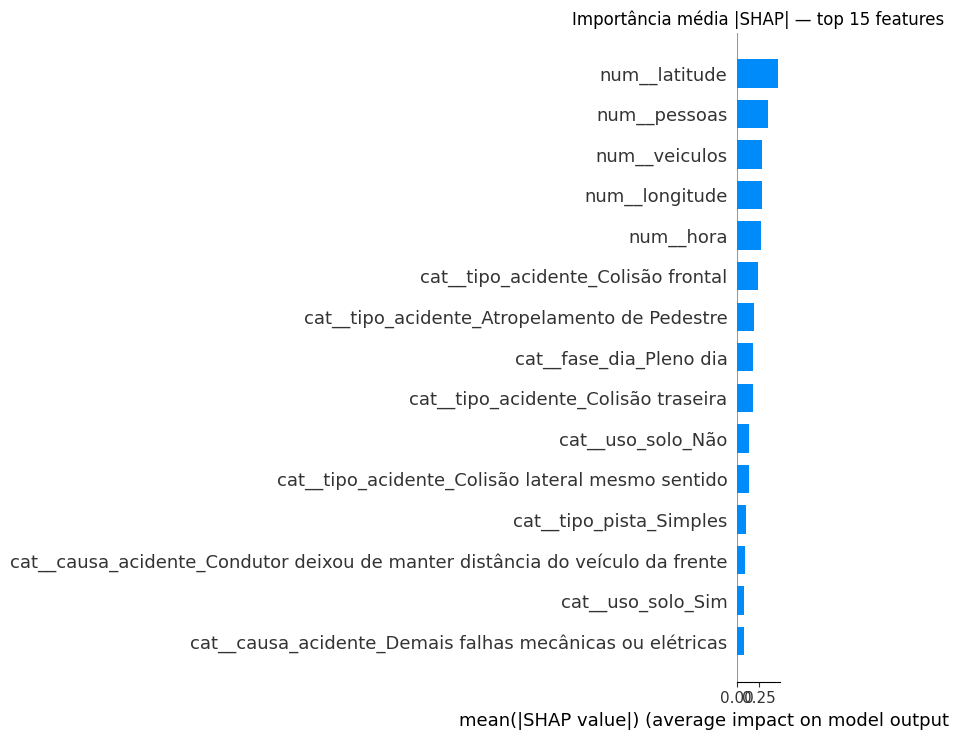

In [4]:
shap.summary_plot(valores_shap, Xt_denso, feature_names=nomes_features,
                   plot_type='bar', max_display=15, show=False)
plt.title('Importância média |SHAP| — top 15 features')
plt.tight_layout()
plt.savefig('../reports/shap_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentário:** as cinco features mais importantes são `latitude`, `pessoas`, `veiculos`, `longitude` e `hora` — variáveis numéricas simples superam a maioria das categóricas isoladas. Entre as categorias, o tipo do acidente domina: `tipo_acidente_Colisão frontal` e `tipo_acidente_Atropelamento de Pedestre` estão entre as mais influentes — coerente com o que se sabe sobre acidentes de trânsito no mundo real (colisão frontal e atropelamento são os tipos com maior letalidade).

## 5. Direção do efeito (beeswarm)

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.


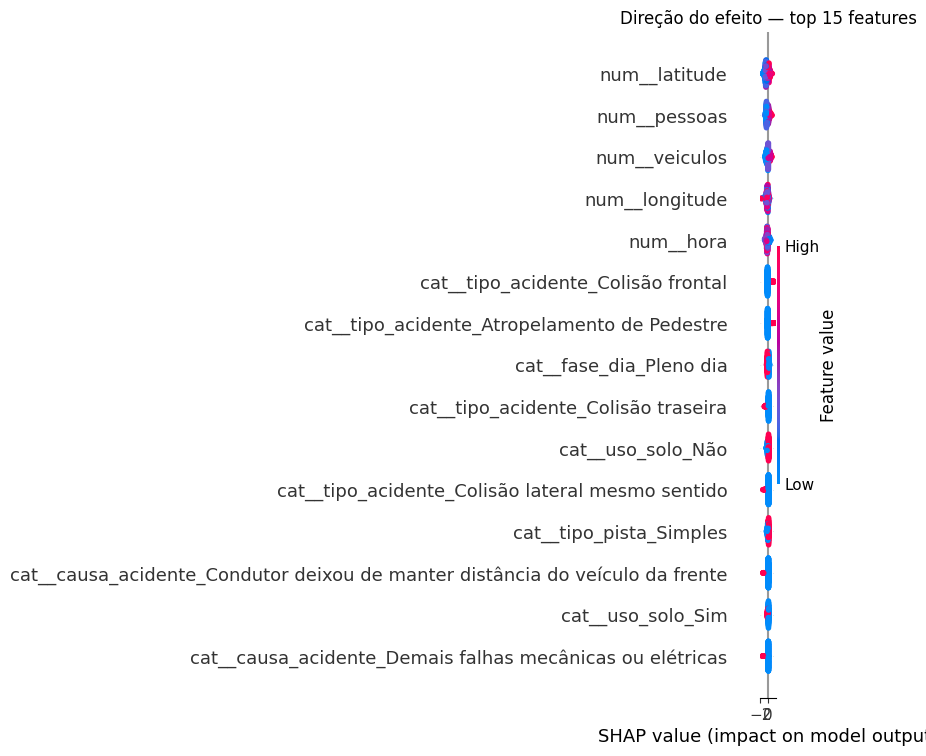

In [5]:
shap.summary_plot(valores_shap, Xt_denso, feature_names=nomes_features, max_display=15, show=False)
plt.title('Direção do efeito — top 15 features')
plt.tight_layout()
plt.savefig('../reports/shap_direcao_efeito.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentário:** o beeswarm confirma direções que fazem sentido no mundo real. `pessoas` e `veiculos` altos empurram a previsão para fatal (correlação valor↔SHAP de 0,79 e 0,87) — mais gente e mais veículos envolvidos, mais chance de óbito. `hora` tem correlação negativa (-0,35): horários mais tarde no dia reduzem o risco previsto, ou seja, **madrugada/início da manhã aumentam o risco** — consistente com `fase_dia_Pleno dia`, que reduz o risco quando ativo (SHAP médio -0,20) e aumenta quando não é dia pleno (+0,15). `tipo_acidente_Colisão frontal` e `Atropelamento de Pedestre` têm SHAP médio de **+1,08 e +1,28** quando ativos (fortíssimo empurrão para fatal), enquanto `Colisão traseira` empurra na direção oposta (**-0,58**) — bate com a intuição de que colisão traseira costuma ser menos grave que colisão frontal ou atropelamento.

## 6. Explicação local — um caso verdadeiro positivo

Casos fatais corretamente identificados na amostra: 17
Probabilidade prevista para este caso: 0.8051


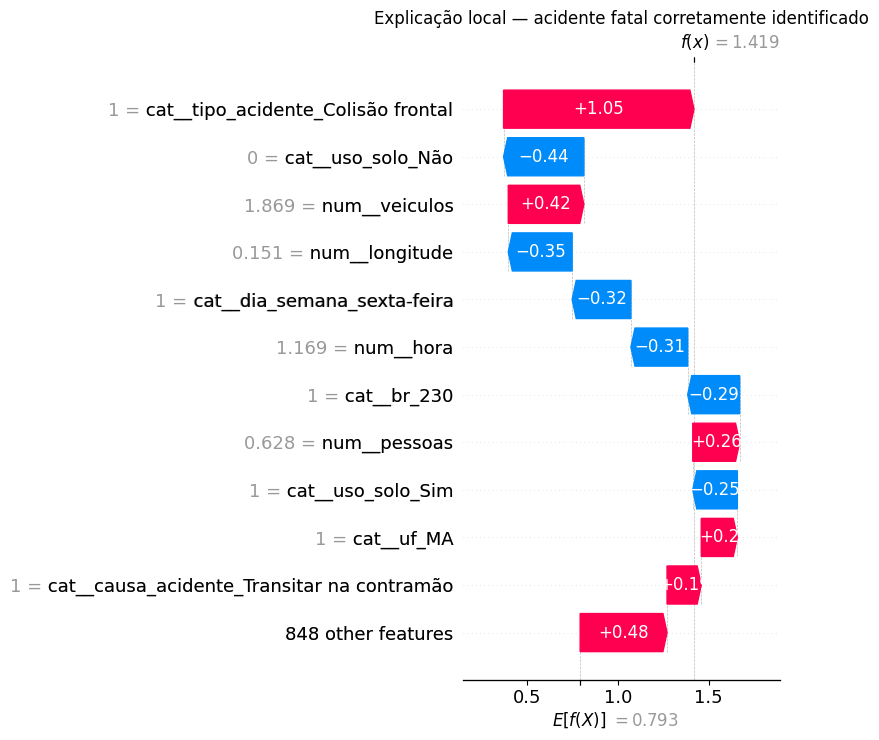

In [6]:
proba_amostra = pipeline.predict_proba(amostra)[:, 1]
candidatos = np.where((y_amostra.values == 1) & (proba_amostra >= limiar))[0]
print('Casos fatais corretamente identificados na amostra:', len(candidatos))

idx = candidatos[0]
print('Probabilidade prevista para este caso:', round(proba_amostra[idx], 4))

explicacao = shap.Explanation(
    values=valores_shap[idx], base_values=explainer.expected_value,
    data=Xt_denso[idx], feature_names=nomes_features)
shap.plots.waterfall(explicacao, show=False, max_display=12)
plt.title('Explicação local — acidente fatal corretamente identificado')
plt.tight_layout()
plt.savefig('../reports/shap_exemplo_local.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentário:** o waterfall mostra, feature a feature, como o modelo saiu do valor-base (a probabilidade média do conjunto de treino, em log-odds) até a previsão final para este acidente específico — cada barra é a contribuição de uma variável isolada. É a diferença entre saber que "o modelo funciona" (métricas agregadas dos notebooks anteriores) e conseguir explicar uma decisão individual, o que importa bastante em um contexto onde a previsão pode orientar prioridade de resposta a acidentes.

## 7. Conclusão

- Localização (`latitude`/`longitude`), porte do acidente (`pessoas`/`veiculos`) e horário são as variáveis numéricas mais influentes; entre as categorias, o **tipo de colisão** domina — frontal e atropelamento aumentam muito o risco previsto, colisão traseira reduz.
- Os sinais encontrados (madrugada mais arriscada, colisão frontal mais letal, mais pessoas/veículos aumentando o risco) são consistentes com o que se sabe sobre segurança viária — um sinal de que o modelo aprendeu padrões plausíveis, não artefatos espúrios.
- Lição técnica: nunca densificar uma matriz esparsa de one-hot antes de calcular SHAP (ou prever) com XGBoost — o significado de "zero" muda, e o modelo passa a se comportar de forma diferente da que foi treinada/avaliada nos notebooks anteriores.
- Próximo passo: empacotar o modelo final por trás de uma API mínima de predição → `src/api.py`.